<a href="https://colab.research.google.com/github/np3342-pixel/MorgageQuestDPA/blob/main/RF_Model_for_DPA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt

### 1. Data Generation (Synthetic Dataset)

Since no specific data was provided, we'll create a synthetic dataset that simulates DPA eligibility factors. In a real-world scenario, you would load your data from a CSV, database, or other source.

## DPA Eligibility Classification with Random Forest

This notebook demonstrates how to build a machine learning model using a Random Forest classifier to predict DPA eligibility. We'll start with creating a synthetic dataset, followed by data preprocessing, model training, and evaluation.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/DPA Analysis/DPA FINAL DATASET1 Z.csv')

In [ ]:
display(df.head())
print(f"Dataset shape: {df.shape}")
print(f"Target approval counts:\n{df['target_approval'].value_counts()}")

,derived_dwelling_category,preapproval,loan_type,loan_purpose,lien_status,loan_amount,loan_to_value_ratio,interest_rate,rate_spread,total_loan_costs,...,tract_to_msa_income_percentage,income_to_loan,price_to_income,dti_cltv_interaction,high_dti_flag,high_cltv_flag,within_income_limit_flag,within_price_limit_flag,first_time_homebuyer_flag,target_approval
0,Single Family (1-4 Units):Site-Built,2,1,2,2,105000.0,77.48,0.0,0.0,0.0,...,100,0.180952,20.000000,0.503620,1,0,1,0,0,0
1,Single Family (1-4 Units):Site-Built,2,1,1,2,505000.0,65.26,0.0,0.0,0.0,...,130,0.429703,4.216590,0.234936,0,0,0,0,1,0
2,Single Family (1-4 Units):Site-Built,2,1,2,1,205000.0,50.00,0.0,0.0,0.0,...,74,0.892683,2.213115,0.125000,0,0,1,1,0,0
3,Single Family (1-4 Units):Site-Built,2,1,31,1,55000.0,19.51,0.0,0.0,0.0,...,130,0.727273,6.375000,0.126815,1,0,1,1,0,0
4,Single Family (1-4 Units):Site-Built,2,1,2,2,75000.0,62.57,0.0,0.0,0.0,...,83,1.000000,11.266667,0.344135,1,0,1,0,0,0


Dataset shape: (10055, 34)
Target approval counts:
target_approval
0    6572
1    3483
Name: count, dtype: int64


### 2. Data Preprocessing

Before training the model, we need to preprocess the data. This involves:
- Encoding categorical features into a numerical format.
- Splitting the data into training and testing sets.

In [ ]:
# Identify categorical and numerical features
categorical_features = df.select_dtypes(include=['object']).columns
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.drop('target_approval')

print(f"Categorical Features: {list(categorical_features)}")
print(f"Numerical Features: {list(numerical_features)}")

# Apply One-Hot Encoding to categorical features
df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=True)

# Define features (X) and target (y) - these are the original, unbalanced data
X = df_encoded.drop('target_approval', axis=1)
y = df_encoded['target_approval']

# Handle missing values in X before applying undersampling
X_filled = X.fillna(X.mean())

# Drop features identified with NaN correlations (no variance or all nulls)
problematic_features = ['negative_amortization', 'total_units_25-49', 'total_units_45413']
# Ensure these features exist in X_filled before attempting to drop
features_to_drop = [f for f in problematic_features if f in X_filled.columns]
X_processed = X_filled.drop(columns=features_to_drop, errors='ignore')

# Split the data (after filling NaNs and dropping problematic features) into training and testing sets without balancing
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.3, random_state=42, stratify=y)

print(f"\nTraining set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
display(X_train.head())

Categorical Features: ['derived_dwelling_category', 'total_units', 'debt_to_income_ratio']
Numerical Features: ['preapproval', 'loan_type', 'loan_purpose', 'lien_status', 'loan_amount', 'loan_to_value_ratio', 'interest_rate', 'rate_spread', 'total_loan_costs', 'origi0tion_charges', 'lender_credits', 'loan_term', 'negative_amortization', 'interest_only_payment', 'balloon_payment', 'property_value', 'occupancy_type', 'income_actual', 'dti_numeric', 'aus-1', 'area_median_income', 'tract_to_msa_income_percentage', 'income_to_loan', 'price_to_income', 'dti_cltv_interaction', 'high_dti_flag', 'high_cltv_flag', 'within_income_limit_flag', 'within_price_limit_flag', 'first_time_homebuyer_flag']

Training set shape: (7038, 55)
Test set shape: (3017, 55)


,preapproval,loan_type,loan_purpose,lien_status,loan_amount,loan_to_value_ratio,interest_rate,rate_spread,total_loan_costs,origi0tion_charges,...,debt_to_income_ratio_43,debt_to_income_ratio_44,debt_to_income_ratio_45,debt_to_income_ratio_46,debt_to_income_ratio_47,debt_to_income_ratio_48,debt_to_income_ratio_49,debt_to_income_ratio_50%-60%,debt_to_income_ratio_<20%,debt_to_income_ratio_>60%
4846,2,1,4,2,35000.0,73.11,0.00,0.00,0.0,0.0,...,False,False,False,False,False,False,False,False,False,True
1501,2,1,1,1,75000.0,70.39,0.00,0.00,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
3316,2,1,2,2,35000.0,85.35,0.00,0.00,0.0,0.0,...,False,False,False,False,False,False,True,False,False,False
4341,2,1,2,2,95000.0,80.00,7.49,2.31,0.0,0.0,...,False,False,True,False,False,False,False,False,False,False
405,2,1,31,1,35000.0,3.33,0.00,0.00,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False


### 3. Model Training - Random Forest Classifier

Now we will train a Random Forest classifier. Random Forest is an ensemble learning method that operates by constructing a multitude of decision trees at training time and outputting the class that is the mode of the classes (classification) or mean prediction (regression) of the individual trees.

In [ ]:
# Initialize and train the Random Forest Classifier
# You can tune hyperparameters like n_estimators (number of trees), max_depth, etc.
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_classifier.fit(X_train, y_train)

print("Random Forest Classifier trained successfully!")

Random Forest Classifier trained successfully!


### 4. Model Evaluation

After training, it's crucial to evaluate the model's performance on unseen data (the test set). We'll use common metrics like accuracy, precision, recall, F1-score, and a confusion matrix.


--- Model Evaluation ---
Accuracy: 0.9917

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1972
           1       0.98      1.00      0.99      1045

    accuracy                           0.99      3017
   macro avg       0.99      0.99      0.99      3017
weighted avg       0.99      0.99      0.99      3017



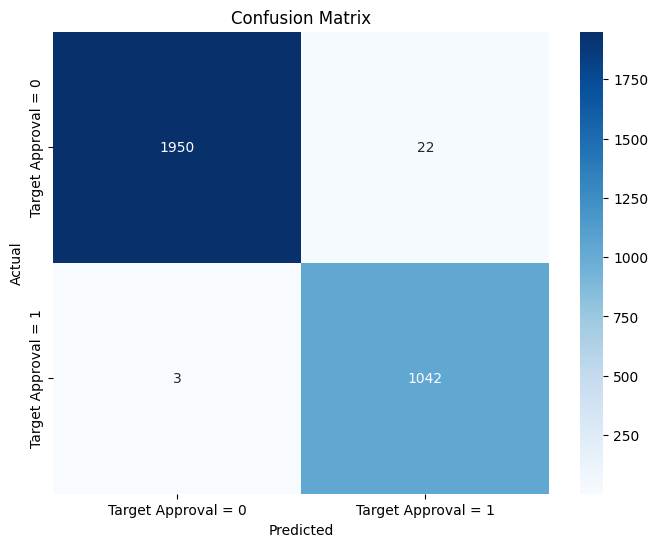

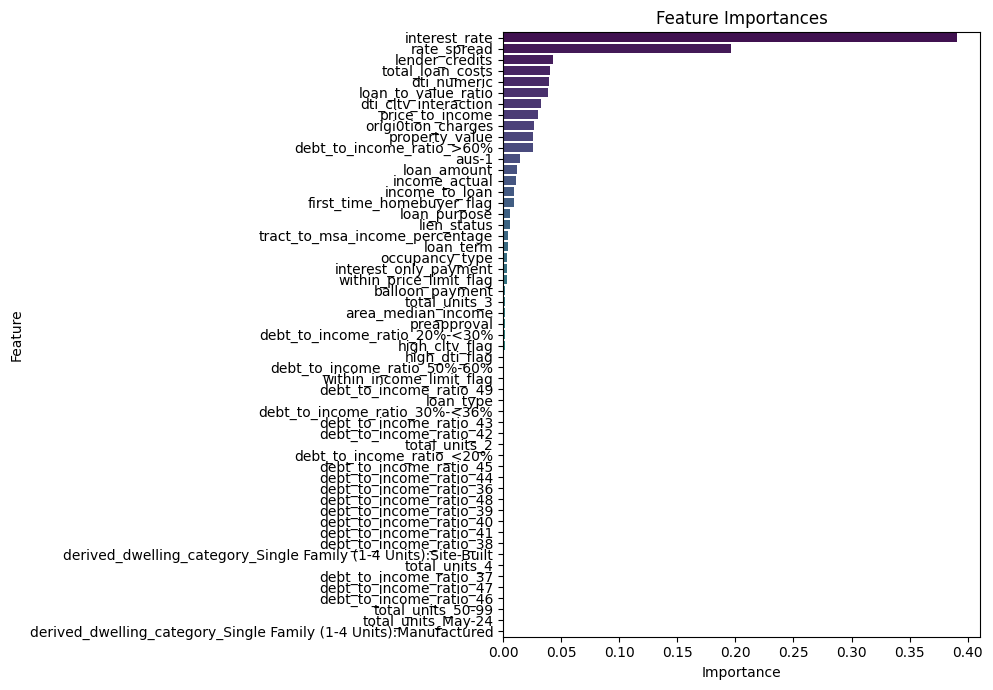

In [ ]:
# Make predictions on the test set
y_pred = rf_classifier.predict(X_test)

# Evaluate the model
print("\n--- Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Target Approval = 0', 'Target Approval = 1'],
            yticklabels=['Target Approval = 0', 'Target Approval = 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Feature Importance
# Update: X_resampled is no longer defined, using X_train for feature importance
feature_importances = pd.Series(rf_classifier.feature_importances_, index=X_train.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 7))
sns.barplot(x=feature_importances, y=feature_importances.index, hue=feature_importances.index, palette='viridis', legend=False)
plt.title('Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

ROC AUC Score: 0.9964


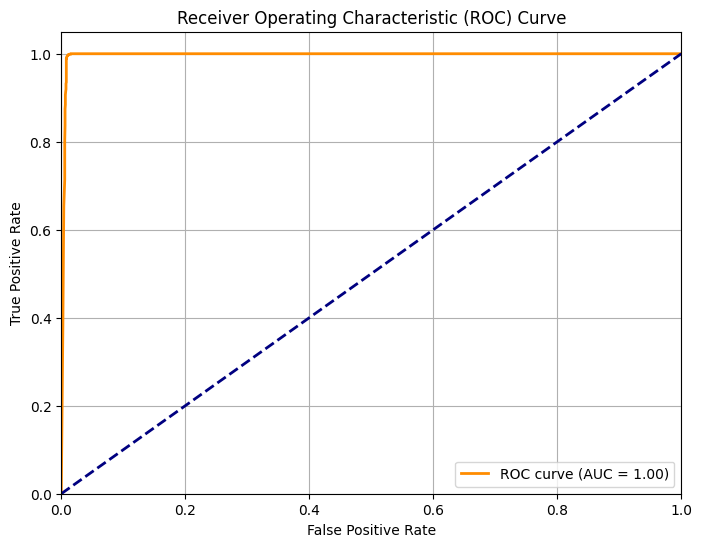

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Predict probabilities for the positive class
y_pred_proba = rf_classifier.predict_proba(X_test)[:, 1]

# Calculate ROC AUC score
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC AUC Score: {roc_auc:.4f}")

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### 5. Cross-Validation for Robust Evaluation

To ensure the model's robustness and to get a more reliable performance estimate, we will perform k-fold cross-validation. This technique helps in detecting overfitting by training and evaluating the model on different subsets of the data.

In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Initialize the Random Forest Classifier with the same parameters
rf_classifier_cv = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# Initialize StratifiedKFold for classification tasks to maintain class balance in each fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation on the training data
# We will use accuracy as the scoring metric, but other metrics can be used as well (e.g., 'f1', 'roc_auc')
cv_scores = cross_val_score(rf_classifier_cv, X_train, y_train, cv=skf, scoring='accuracy')

print(f"Cross-validation accuracy scores: {cv_scores}")
print(f"Mean cross-validation accuracy: {np.mean(cv_scores):.4f}")
print(f"Standard deviation of cross-validation accuracy: {np.std(cv_scores):.4f}")

# You can also get other metrics using cross_validate function for more detailed results
from sklearn.model_selection import cross_validate

scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
cv_results = cross_validate(rf_classifier_cv, X_train, y_train, cv=skf, scoring=scoring)

print("\nCross-validation results for multiple metrics:")
for metric in scoring:
    print(f"{metric.capitalize()}: {np.mean(cv_results[f'test_{metric}']):.4f} (+/- {np.std(cv_results[f'test_{metric}']):.4f})")

Cross-validation accuracy scores: [0.98650568 0.98863636 0.99005682 0.99289268 0.98933902]
Mean cross-validation accuracy: 0.9895
Standard deviation of cross-validation accuracy: 0.0021

Cross-validation results for multiple metrics:
Accuracy: 0.9895 (+/- 0.0021)
Precision: 0.9770 (+/- 0.0041)
Recall: 0.9930 (+/- 0.0031)
F1: 0.9850 (+/- 0.0030)
Roc_auc: 0.9975 (+/- 0.0012)


### 6. Correlation Matrix Analysis (for Data Leakage/Redundancy)

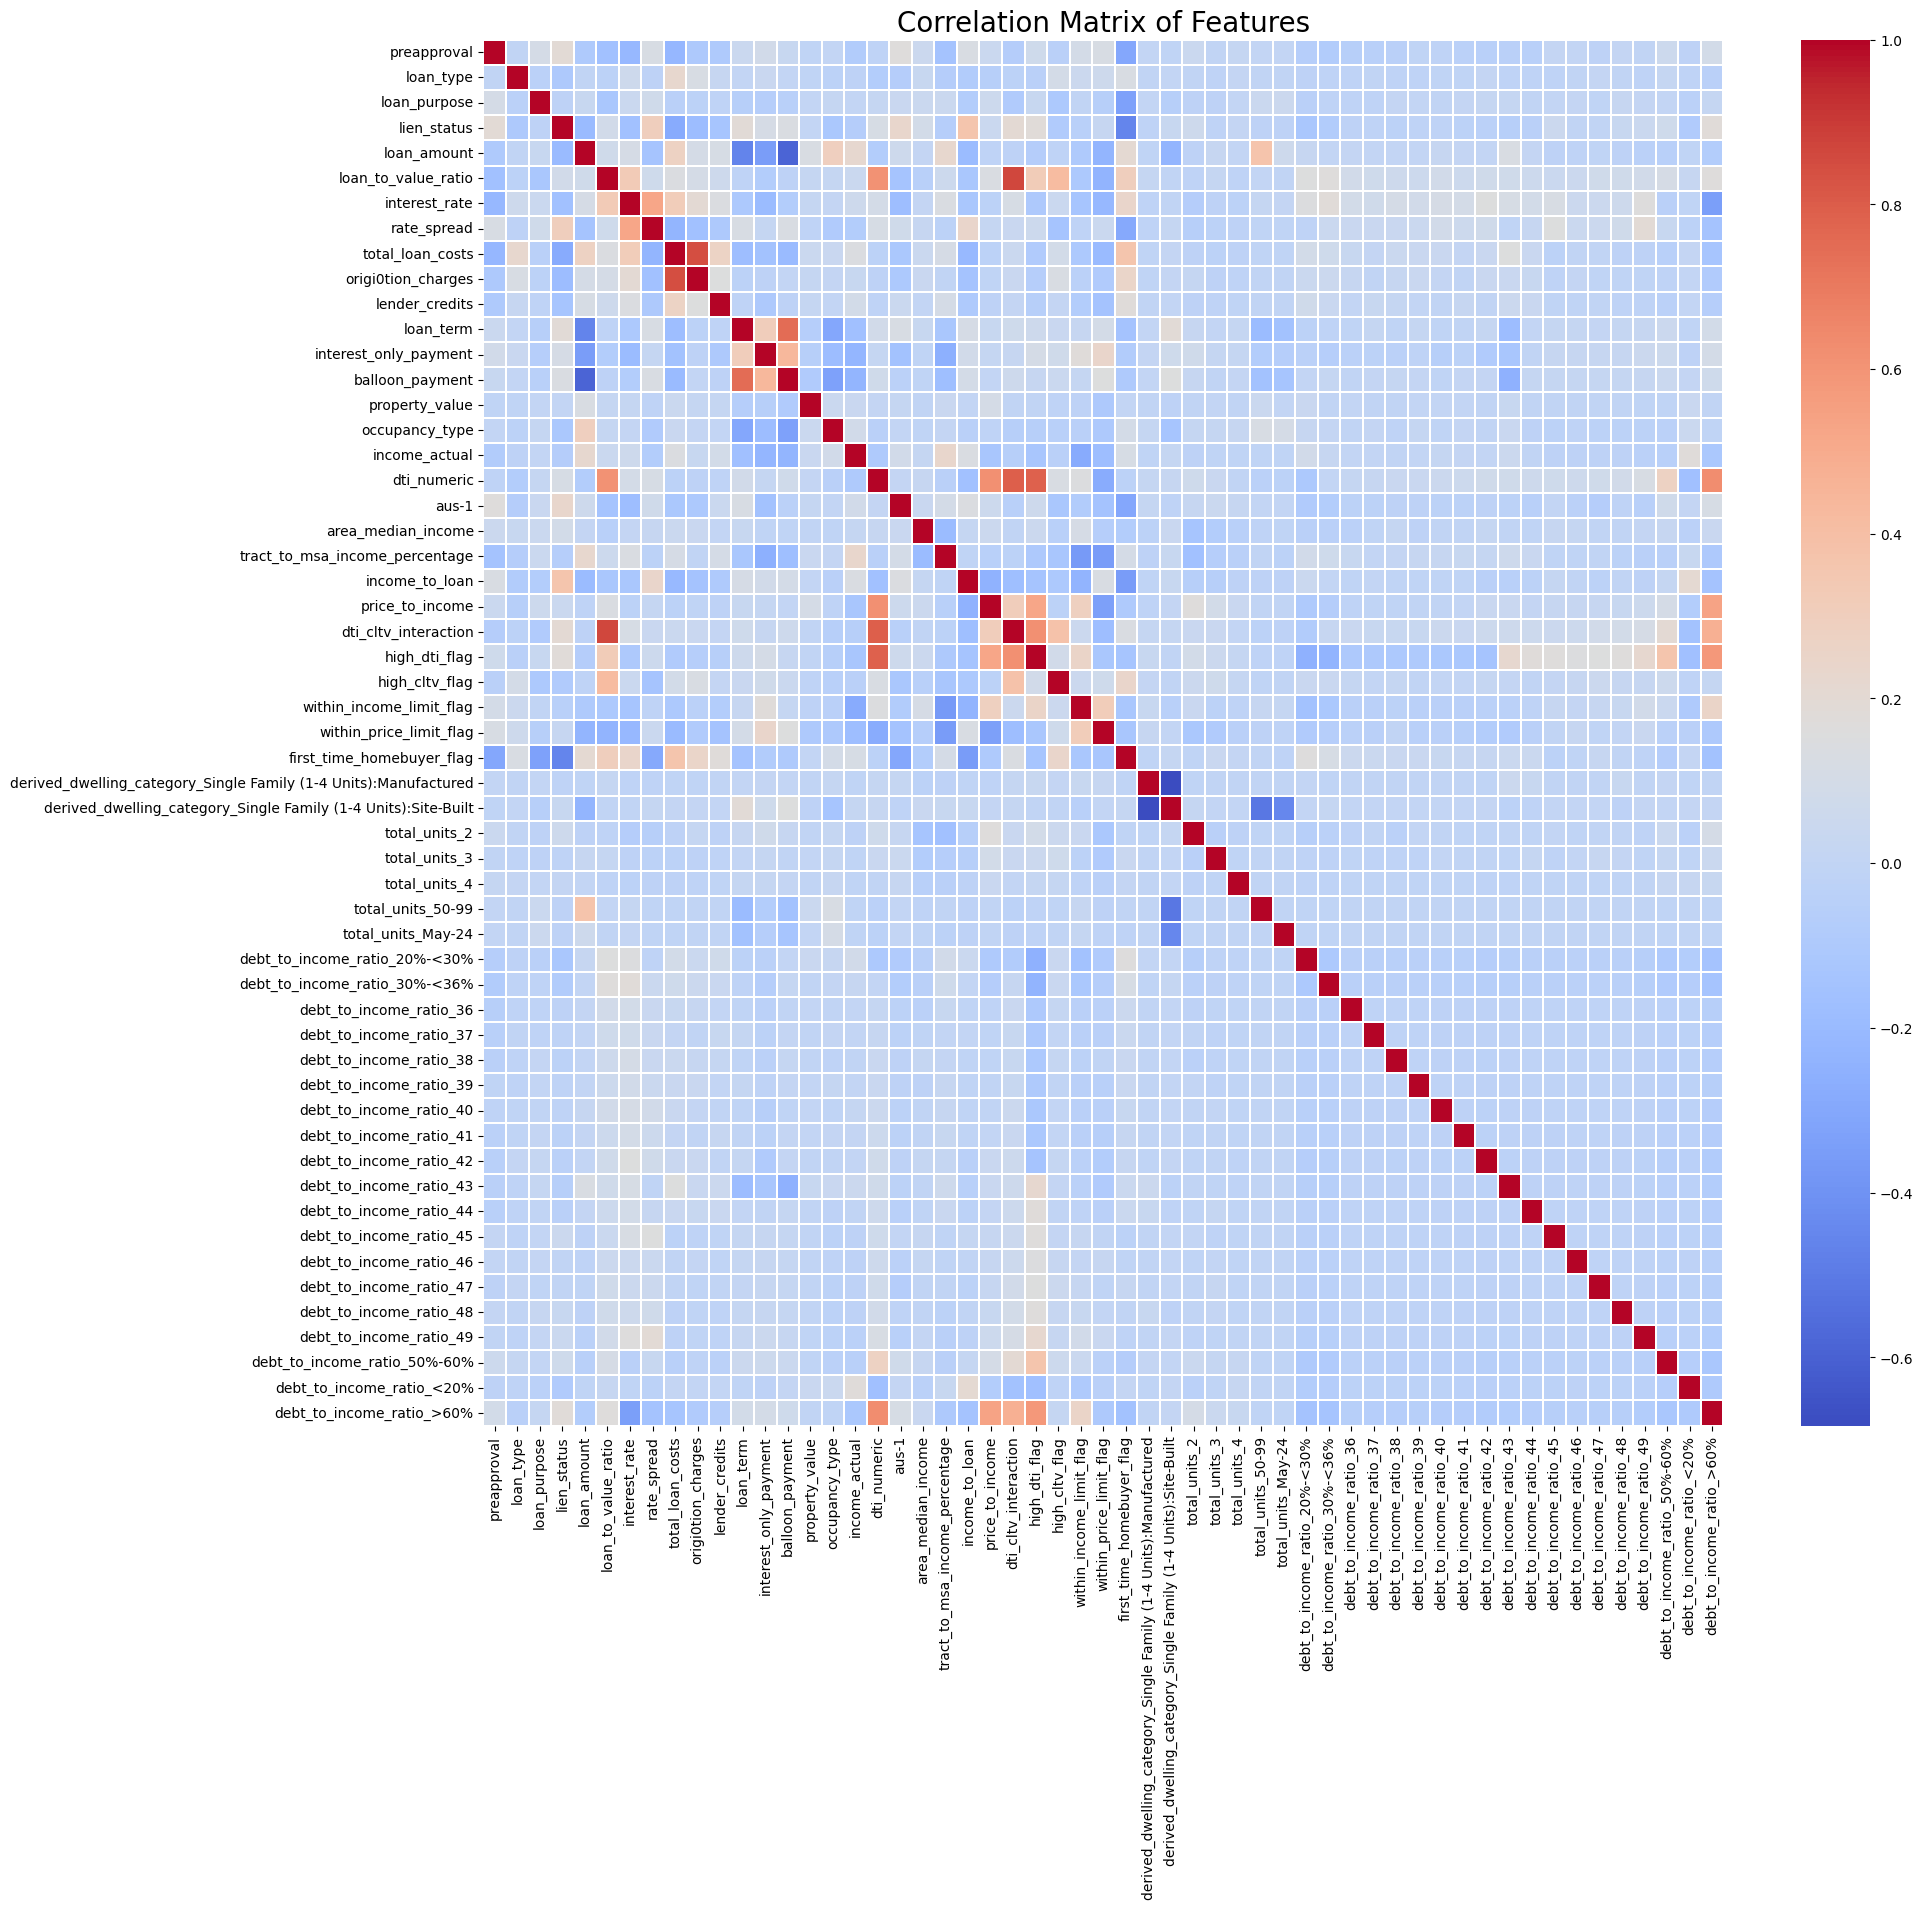


No highly correlated feature pairs found (absolute correlation > 0.9).


In [ ]:
# Calculate the correlation matrix for the training features (X_train)
correlation_matrix = X_train.corr()

# Set up the matplotlib figure
plt.figure(figsize=(20, 18))

# Draw the heatmap with seaborn
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.05)
plt.title('Correlation Matrix of Features', fontsize=20)
plt.show()

# Identify highly correlated features (e.g., correlation > 0.9 or < -0.9)
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > 0.9:
            colname1 = correlation_matrix.columns[i]
            colname2 = correlation_matrix.columns[j]
            high_corr_pairs.append(f"{colname1} - {colname2}: {correlation_matrix.iloc[i, j]:.2f}")

if high_corr_pairs:
    print("\nHighly correlated feature pairs (absolute correlation > 0.9):")
    for pair in high_corr_pairs:
        print(pair)
else:
    print("\nNo highly correlated feature pairs found (absolute correlation > 0.9).")

### 7. Hyperparameter Tuning to Combat Overfitting

Given the perfect accuracy, which strongly suggests overfitting, we will perform hyperparameter tuning using `GridSearchCV`. This will help us find a more generalized model by systematically searching for the best combination of hyperparameters that might reduce model complexity and prevent memorization of the training data.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'n_estimators': [50, 100, 150],  # Number of trees in the forest
    'max_depth': [5, 10, 20, None], # Maximum depth of the tree (None means unlimited)
    'min_samples_leaf': [1, 2, 4], # Minimum number of samples required to be at a leaf node
    'min_samples_split': [2, 5, 10] # Minimum number of samples required to split an internal node
}

# Initialize a new Random Forest Classifier
rf_tuned = RandomForestClassifier(random_state=42, class_weight='balanced')

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=rf_tuned, param_grid=param_grid,
                           cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                           scoring='accuracy', n_jobs=-1, verbose=2)

# Fit GridSearchCV to the resampled data
print("Starting Grid Search for optimal hyperparameters...")
grid_search.fit(X_train, y_train)

print("Grid Search complete!")
print(f"Best hyperparameters found: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

# Get the best model
best_rf_model = grid_search.best_estimator_

Starting Grid Search for optimal hyperparameters...
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Grid Search complete!
Best hyperparameters found: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 50}
Best cross-validation accuracy: 0.9905



Correlation of Features with Target Approval:
target_approval                                                     1.000000
interest_rate                                                       0.895449
rate_spread                                                         0.434267
loan_to_value_ratio                                                 0.381990
total_loan_costs                                                    0.329376
first_time_homebuyer_flag                                           0.252543
origi0tion_charges                                                  0.202996
debt_to_income_ratio_30%-<36%                                       0.190525
debt_to_income_ratio_20%-<30%                                       0.175803
dti_cltv_interaction                                                0.162069
lender_credits                                                      0.157227
debt_to_income_ratio_42                                             0.152244
tract_to_msa_income_percentag

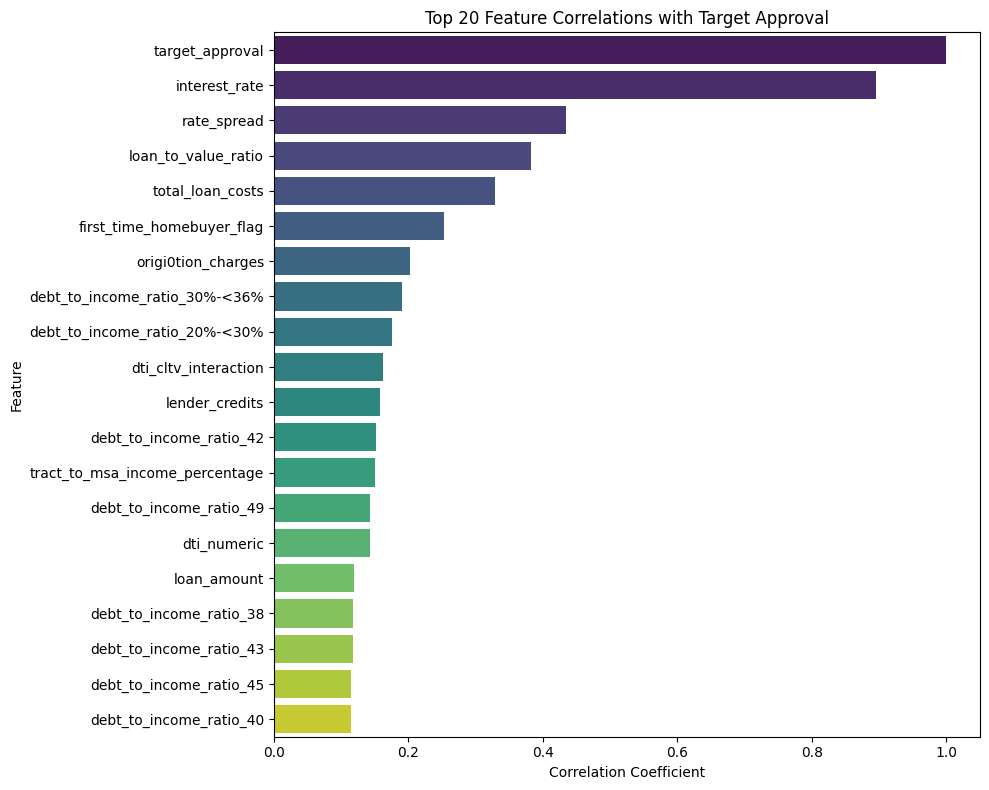

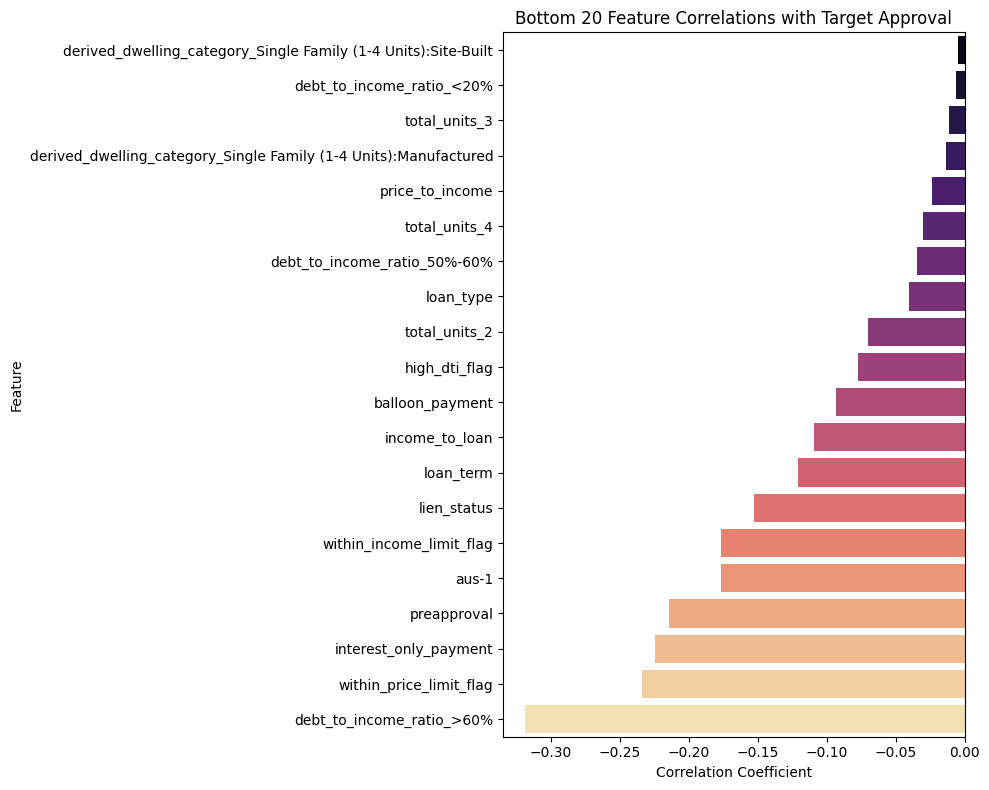

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Combine X_train and y_train to calculate correlations with the target
train_data_with_target = X_train.copy()
train_data_with_target['target_approval'] = y_train

# Calculate the correlation of all features with the target variable
target_correlations = train_data_with_target.corr()['target_approval'].sort_values(ascending=False)

print("\nCorrelation of Features with Target Approval:")
print(target_correlations)

# Visualize the top N correlations
plt.figure(figsize=(10, 8))
sns.barplot(x=target_correlations.head(20).values, y=target_correlations.head(20).index, hue=target_correlations.head(20).index, palette='viridis', legend=False)
plt.title('Top 20 Feature Correlations with Target Approval')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
sns.barplot(x=target_correlations.tail(20).values, y=target_correlations.tail(20).index, hue=target_correlations.tail(20).index, palette='magma', legend=False)
plt.title('Bottom 20 Feature Correlations with Target Approval')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [ ]:
import joblib
import os

# Define the path to save the model in your Google Drive
save_path = '/content/drive/MyDrive/DPA Analysis/rf_classifier.joblib'

# Ensure the directory exists (optional, but good practice)
os.makedirs(os.path.dirname(save_path), exist_ok=True)

# Save the trained rf_classifier model using joblib
joblib.dump(rf_classifier, save_path)

print(f"Random Forest model saved successfully to: {save_path}")

Random Forest model saved successfully to: /content/drive/MyDrive/DPA Analysis/rf_classifier.joblib


### 8. Convert Model to ONNX Format

To use the trained Random Forest model in other environments, especially those supporting ONNX runtime (like Node.js, as you mentioned), we can convert it to the Open Neural Network Exchange (ONNX) format using `skl2onnx`.

In [ ]:
# Install skl2onnx if not already installed
!pip install skl2onnx onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.2/317.2 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 38.2 MB/s eta 0:00:00


In [ ]:
import joblib
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType
import os

# Define the path to the saved joblib model
joblib_path = '/content/drive/MyDrive/DPA Analysis/rf_classifier.joblib'

# Load the trained Random Forest model
rf_classifier_loaded = joblib.load(joblib_path)

# Define the input types for the ONNX model
# X_train is available from previous steps and represents the input feature shape
initial_type = [('float_input', FloatTensorType([None, X_train.shape[1]]))]

# Convert the scikit-learn model to ONNX format
onx = convert_sklearn(rf_classifier_loaded, initial_types=initial_type, target_opset=13)

# Define the path to save the ONNX model
onnx_save_path = '/content/drive/MyDrive/DPA Analysis/rf_classifier.onnx'

# Save the ONNX model
with open(onnx_save_path, "wb") as f:
    f.write(onx.SerializeToString())

print(f"Random Forest model successfully converted and saved to ONNX format: {onnx_save_path}")

Random Forest model successfully converted and saved to ONNX format: /content/drive/MyDrive/DPA Analysis/rf_classifier.onnx


The ONNX model has been saved to your Google Drive. You can now use this `.onnx` file with `onnxruntime-node` in your Node.js application.

### 9. Convert Model to Native JavaScript (using m2cgen)

As an alternative to ONNX, we can convert the Random Forest model directly into a JavaScript function using `m2cgen`. This can be useful for direct integration into JavaScript environments without requiring an ONNX runtime.

In [ ]:
# Install m2cgen if not already installed
!pip install m2cgen

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.2/92.2 kB 1.1 MB/s eta 0:00:00


In [ ]:
import m2cgen as m2c
import joblib
import os

# Define the path to the saved joblib model
joblib_path = '/content/drive/MyDrive/DPA Analysis/rf_classifier.joblib'

# Load the trained Random Forest model
rf_classifier_loaded = joblib.load(joblib_path)

# Convert the model to JavaScript code
js_code = m2c.export_to_javascript(rf_classifier_loaded)

# Define the path to save the JavaScript file
js_save_path = '/content/drive/MyDrive/DPA Analysis/rf_classifier_model.js'

# Save the JavaScript code to a file
with open(js_save_path, 'w') as f:
    f.write(js_code)

print(f"Random Forest model successfully converted to JavaScript and saved to: {js_save_path}")

# Display the first few lines of the generated JavaScript code
print("\n--- First 20 lines of the generated JavaScript code ---")
with open(js_save_path, 'r') as f:
    for i, line in enumerate(f):
        if i >= 20: # Displaying first 20 lines as it can be very long
            break
        print(line, end='')
print("\n... (truncated for brevity) ...")
print("\n--- End of JavaScript code preview ---")

Random Forest model successfully converted to JavaScript and saved to: /content/drive/MyDrive/DPA Analysis/rf_classifier_model.js

--- First 20 lines of the generated JavaScript code ---
function score(input) {
    var var0;
    if (input[8] <= 7.5) {
        if (input[23] <= 0.01396000012755394) {
            if (input[15] <= 2.5) {
                if (input[16] <= 426500.0) {
                    if (input[11] <= 331.0) {
                        var0 = [1.0, 0.0];
                    } else {
                        if (input[4] <= 30000.0) {
                            if (input[19] <= 108350.0) {
                                var0 = [1.0, 0.0];
                            } else {
                                if (input[7] <= 1.3524999618530273) {
                                    var0 = [1.0, 0.0];
                                } else {
                                    var0 = [0.0, 1.0];
                                }
                            }
                    

The JavaScript code for your Random Forest model has been generated and saved to your Google Drive. I've also printed the first 20 lines of the generated code for your review. You can now copy the full content of `rf_classifier_model.js` from your Google Drive and paste it into your chat.